<a href="https://colab.research.google.com/github/adamarsyadfaizin/PCVK26_10_Adam/blob/main/Week6_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PERCOBAAN

NAMA = 'Moch. Adam Arsyad Faizin'
NIM = '244107020164' # ganti dengan NIM sendiri
print(NAMA, NIM)

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Moch. Adam Arysad Faizin'
NIM = '244107020164' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Moch. Adam Arysad Faizin
NIM : 244107020164 | N = 164
bins   : 8
clip   : 3.0
tile   : 2
L      : 8
WAKTU : 2026-10-04 21:47:03 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 5ddb0e52cb8d3d10


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [4]:
def convolution2d(image, kernel, stride, padding):
    image_padded = np.pad(
        image,
        ((padding, padding), (padding, padding)),
        mode='constant'
    )

    h_kernel, w_kernel = kernel.shape

    h_output = ((image.shape[0] + 2 * padding - h_kernel) // stride) + 1
    w_output = ((image.shape[1] + 2 * padding - w_kernel) // stride) + 1

    output = np.zeros((h_output, w_output))

    for y in range(h_output):
        for x in range(w_output):
            y_start = y * stride
            x_start = x * stride

            area = image_padded[
                y_start:y_start + h_kernel,
                x_start:x_start + w_kernel
            ]

            output[y, x] = np.sum(area * kernel)

    return output

In [5]:

img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

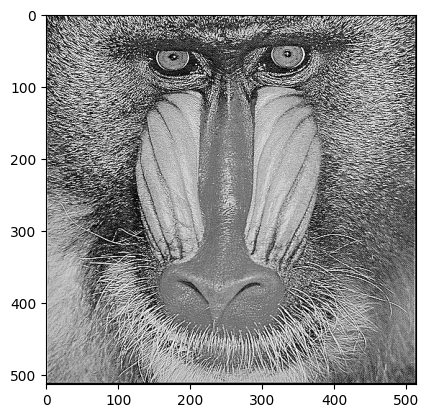

In [6]:
cernel_sharpen = np.array([[0,-1,0],
                          [-1,5,-1],
                          [0,-1,0]])
hasil = convolution2d(img_gray,cernel_sharpen,1,2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)
plt.imshow(hasil, cmap='gray')

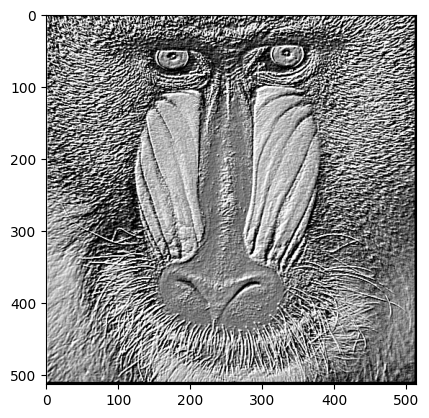

In [7]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cernel_emboss = np.array([[-2,-1,0],
                          [-1,1,1],
                          [0,1,2]])
hasil = convolution2d(img_gray,cernel_emboss,1,2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)
plt.imshow(hasil, cmap='gray')

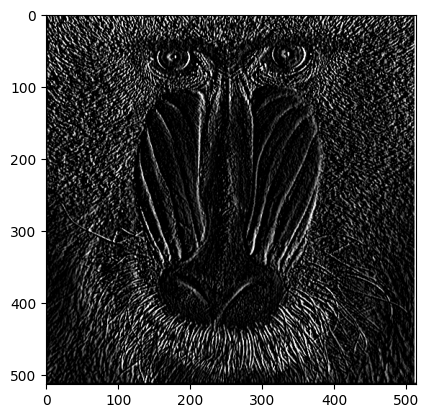

In [8]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cernel_left_sobel_edge_detection = np.array([[1,0,-1],
                                            [2,0,-2],
                                            [1,0,-1]])
hasil = convolution2d(img_gray,cernel_left_sobel_edge_detection,1,2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)
plt.imshow(hasil, cmap='gray')

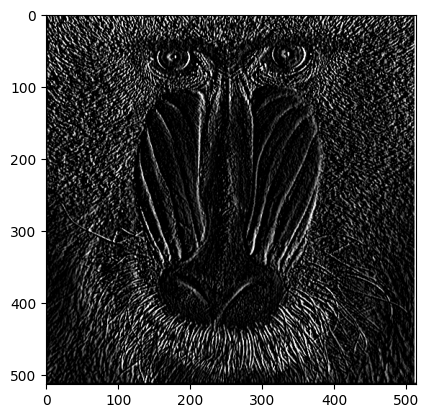

In [9]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cernel_canny_edge_detection = np.array([[1,0,-1],
                                            [2,0,-2],
                                            [1,0,-1]])
hasil = convolution2d(img_gray,cernel_canny_edge_detection,1,2)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)
plt.imshow(hasil, cmap='gray')

Text(0.5, 1.0, '21x21 Gaussian Blur')

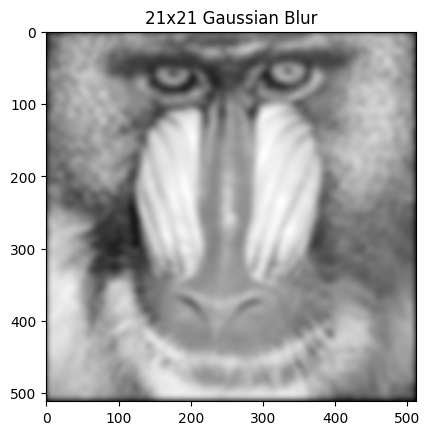

In [10]:
img = cv.imread('/content/drive/MyDrive/PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()
hasil = convolution2d(img_gray, gauss_kernel, 1, 10)
hasil = np.clip(hasil, 0, 255).astype(np.uint8)
plt.imshow(hasil, cmap='gray')
plt.title('21x21 Gaussian Blur')

PERCOBAAN 1

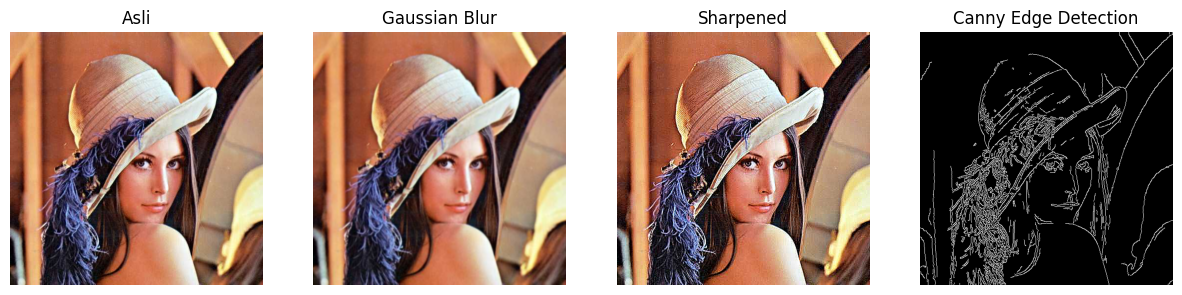

In [11]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

PERCOBAAN 2

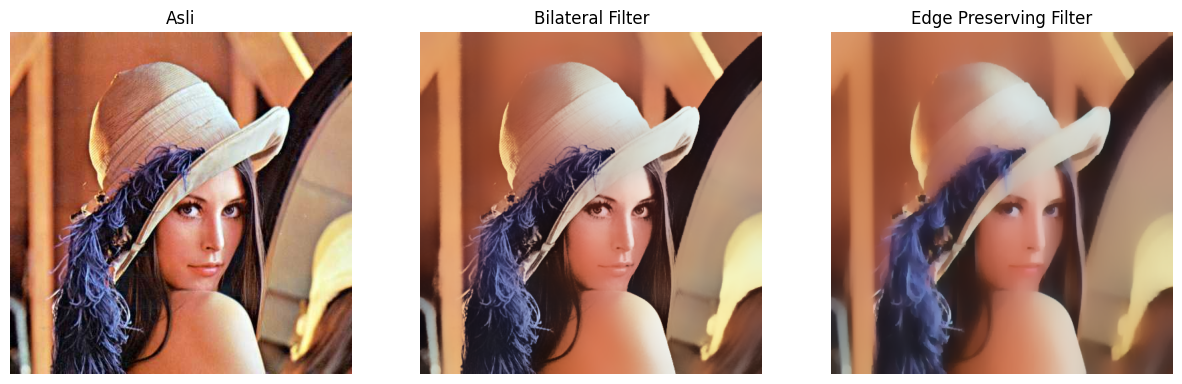

In [12]:
#Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

PERCOBAAN 3

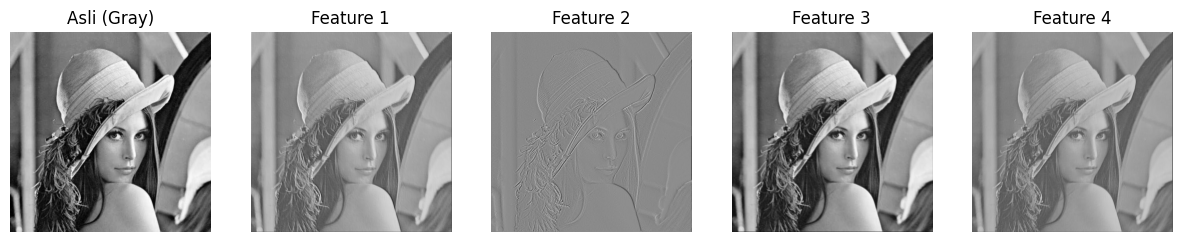

In [13]:
#Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

PERCOBAAN 4

In [14]:
# =====================
# 1. Beauty Filter
# =====================
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# =====================
# 2. Old/Vintage Filter
# =====================
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

PERCOBAAN 5

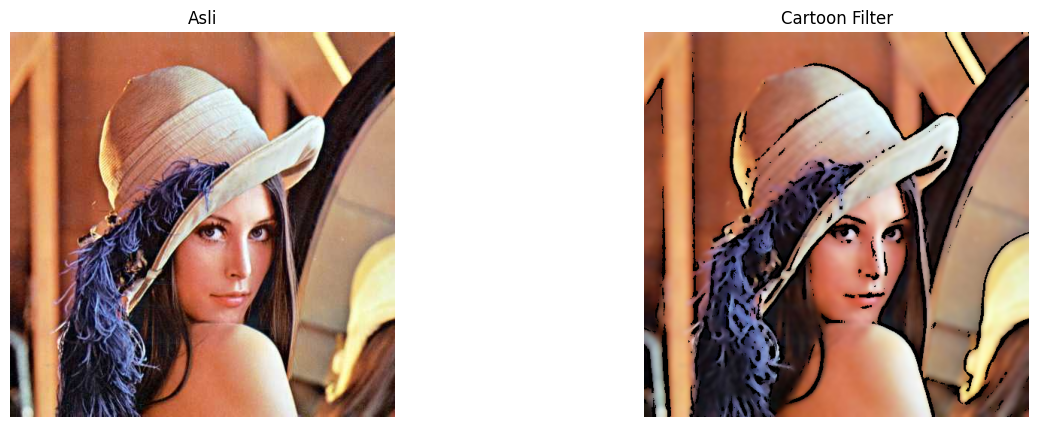

In [15]:
#Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

PERCOBAAN 6

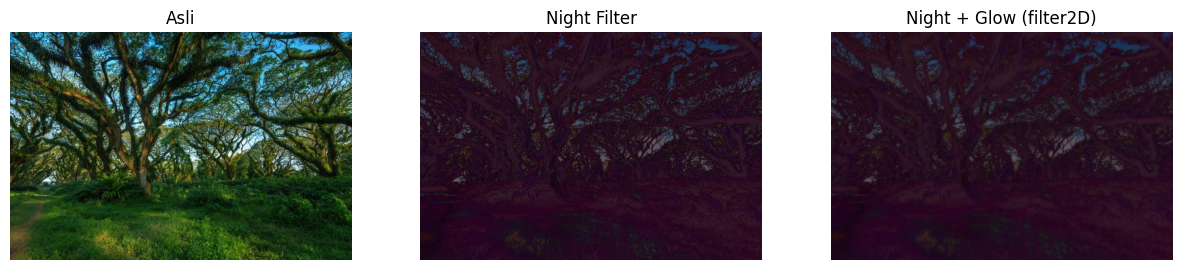

In [16]:
#Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/Images/djawatan.jpg")
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

PERCOBAAN 7

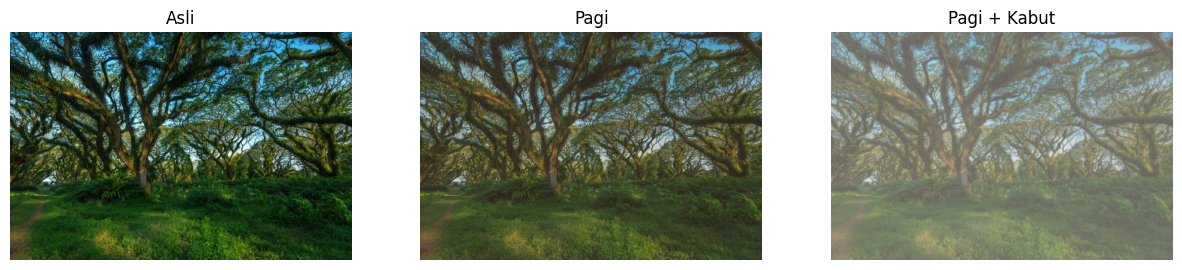

In [17]:
#Filter Suasana pagi dan Kabut
# ========================
# Step 1: Kurangi kontras & cerahkan
# ========================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ========================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])

TUGAS

1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”

a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).

b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).

Pengolahan Citra dan Visi Komputer – Jurusan Teknologi Informasi
c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus
noise tersebut dibanding Mean Filter.

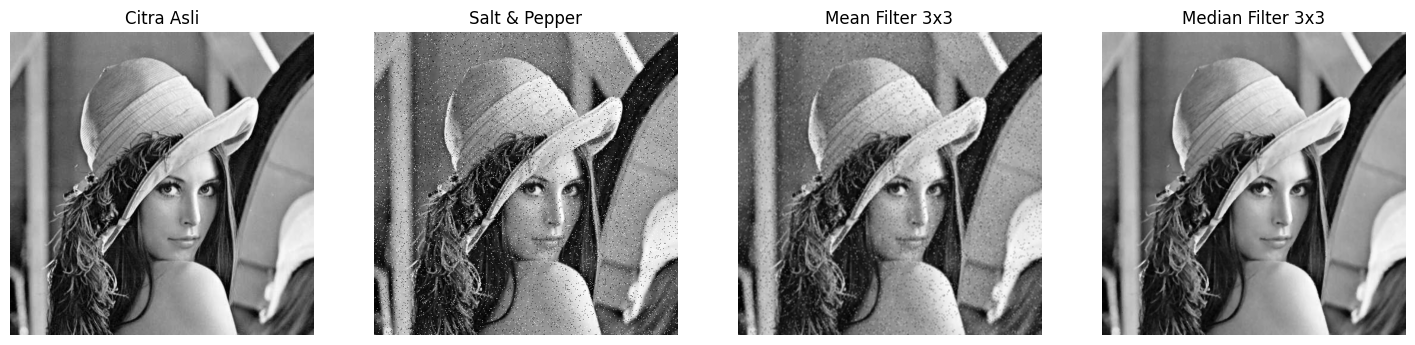

PSNR citra bernoise: 18.08 dB
PSNR Mean Filter : 25.90 dB
PSNR Median Filter: 33.07 dB


In [18]:
img_tugas = cv.imread("/content/drive/MyDrive/PCVK/Images/lena.jpg")
if img_tugas is None:
    raise FileNotFoundError("Citra lena.jpg tidak ditemukan")
gray_tugas = cv.cvtColor(img_tugas, cv.COLOR_BGR2GRAY)
def tambah_salt_pepper(image, amount=0.05, salt_vs_pepper=0.5, seed=164):
    noisy = image.copy()
    rng = np.random.default_rng(seed)
    jumlah_noise = int(amount * image.size)
    indeks = rng.choice(image.size, size=jumlah_noise, replace=False)
    jumlah_salt = int(jumlah_noise * salt_vs_pepper)
    flat = noisy.reshape(-1)
    flat[indeks[:jumlah_salt]] = 255   # Salt (putih)
    flat[indeks[jumlah_salt:]] = 0     # Pepper (hitam)
    return noisy

# Tambahkan noise 5%
noisy_sp = tambah_salt_pepper(gray_tugas, amount=0.05)
# Mean Filter 3x3
mean_3x3 = cv.blur(noisy_sp, (3, 3))
# Median Filter 3x3
median_3x3 = cv.medianBlur(noisy_sp, 3)
# Tampilkan perbandingan
show_side_by_side(
    [gray_tugas, noisy_sp, mean_3x3, median_3x3],
    ["Citra Asli", "Salt & Pepper", "Mean Filter 3x3", "Median Filter 3x3"],
    figsize=(18, 5)
)
# Evaluasi tambahan dengan PSNR terhadap citra asli
print("PSNR citra bernoise: %.2f dB" % cv.PSNR(gray_tugas, noisy_sp))
print("PSNR Mean Filter : %.2f dB" % cv.PSNR(gray_tugas, mean_3x3))
print("PSNR Median Filter: %.2f dB" % cv.PSNR(gray_tugas, median_3x3))


Pada Mean Filter, nilai setiap piksel diganti dengan rata-rata piksel pada lingkungan 3×3. Piksel noise Salt and Pepper memiliki nilai ekstrem, yaitu 0 atau 255. Ketika ikut dirata-ratakan, nilai ekstrem tersebut menyebar ke piksel di sekitarnya sehingga bintik memang berkurang, tetapi berubah menjadi noda abu-abu dan citra ikut menjadi lebih buram.
Pada Median Filter, nilai piksel diganti dengan nilai tengah setelah seluruh nilai pada lingkungan 3×3 diurutkan. Karena nilai 0 dan 255 biasanya hanya berupa pencilan (outlier), keduanya cenderung tidak terpilih sebagai nilai median. Akibatnya noise bintik dapat dihilangkan tanpa terlalu meratakan piksel normal di sekitarnya.
Kesimpulan: untuk noise impulsif seperti Salt and Pepper, Median Filter 3×3 lebih sesuai daripada Mean Filter 3×3 karena lebih efektif membuang piksel ekstrem sekaligus lebih baik dalam mempertahankan tepi objek.

2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)

a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.

b. Terapkan pada citra yang sedikit buram (blurry).

c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.

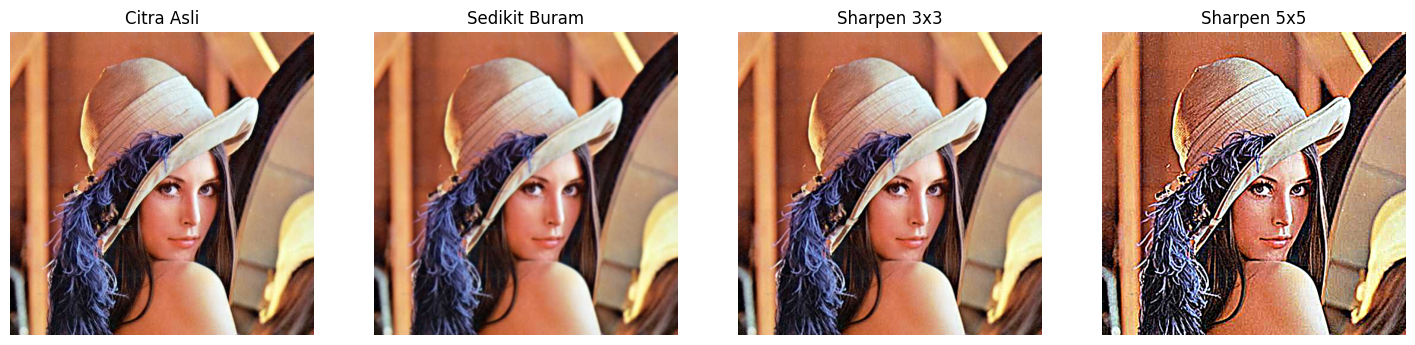

Kernel 3x3:
 [[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]

Kernel 5x5:
 [[ 0.  0. -1.  0.  0.]
 [ 0. -1. -2. -1.  0.]
 [-1. -2. 17. -2. -1.]
 [ 0. -1. -2. -1.  0.]
 [ 0.  0. -1.  0.  0.]]


In [19]:
blur_tugas = cv.GaussianBlur(img_tugas, (5, 5), 1.0)
kernel_sharpen_3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)
kernel_sharpen_5 = np.array([
    [ 0,  0, -1,  0,  0],
    [ 0, -1, -2, -1,  0],
    [-1, -2, 17, -2, -1],
    [ 0, -1, -2, -1,  0],
    [ 0,  0, -1,  0,  0]
], dtype=np.float32)
def terapkan_sharpen(image, kernel):
    hasil = cv.filter2D(image.astype(np.float32), cv.CV_32F, kernel)
    return np.clip(hasil, 0, 255).astype(np.uint8)
sharp_3 = terapkan_sharpen(blur_tugas, kernel_sharpen_3)
sharp_5 = terapkan_sharpen(blur_tugas, kernel_sharpen_5)
show_side_by_side(
    [img_tugas, blur_tugas, sharp_3, sharp_5],
    ["Citra Asli", "Sedikit Buram", "Sharpen 3x3", "Sharpen 5x5"],
    figsize=(18, 5)
)
print("Kernel 3x3:\n", kernel_sharpen_3)
print("\nKernel 5x5:\n", kernel_sharpen_5)

In [20]:
def edge_strength(image):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    return cv.Laplacian(gray, cv.CV_64F).var()
def mae(image_a, image_b):
    a = image_a.astype(np.float32)
    b = image_b.astype(np.float32)
    return np.mean(np.abs(a - b))
print("Asli       : %.2f" % edge_strength(img_tugas))
print("Buram      : %.2f" % edge_strength(blur_tugas))
print("Sharpen 3x3: %.2f" % edge_strength(sharp_3))
print("Sharpen 5x5: %.2f" % edge_strength(sharp_5))
print("Buram      : %.2f" % mae(img_tugas, blur_tugas))
print("Sharpen 3x3: %.2f" % mae(img_tugas, sharp_3))
print("Sharpen 5x5: %.2f" % mae(img_tugas, sharp_5))

Asli       : 498.28
Buram      : 61.62
Sharpen 3x3: 337.09
Sharpen 5x5: 3939.88
Buram      : 3.57
Sharpen 3x3: 2.60
Sharpen 5x5: 19.12


Kernel 3×3 bekerja pada lingkungan yang lebih kecil sehingga penajaman bersifat lebih lokal. Tepi objek menjadi lebih jelas, tetapi tekstur halus dan noise tidak terlalu diperkuat. Hasilnya cenderung terlihat lebih natural.
Kernel 5×5 melibatkan lingkungan yang lebih luas dan pada kernel yang digunakan efek penajamannya lebih agresif. Tepi dapat terlihat sangat tegas, tetapi perubahan intensitas di sekitar tepi juga semakin besar. Efek samping yang dapat terlihat adalah noise/tekstur kasar ikut diperkuat serta munculnya halo atau garis terang-gelap di sekitar batas objek.
Kesimpulan: kernel 3×3 lebih optimal untuk penggunaan sehari-hari karena memberikan kompromi yang lebih baik antara kejelasan tepi dan distorsi. Kernel 5×5 masih berguna jika citra memang membutuhkan penajaman yang kuat, tetapi harus digunakan lebih hati-hati karena lebih mudah memperkuat noise dan menghasilkan artefak.

3. Tugas Kreasi: Filter Kartun Sederhana

a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.

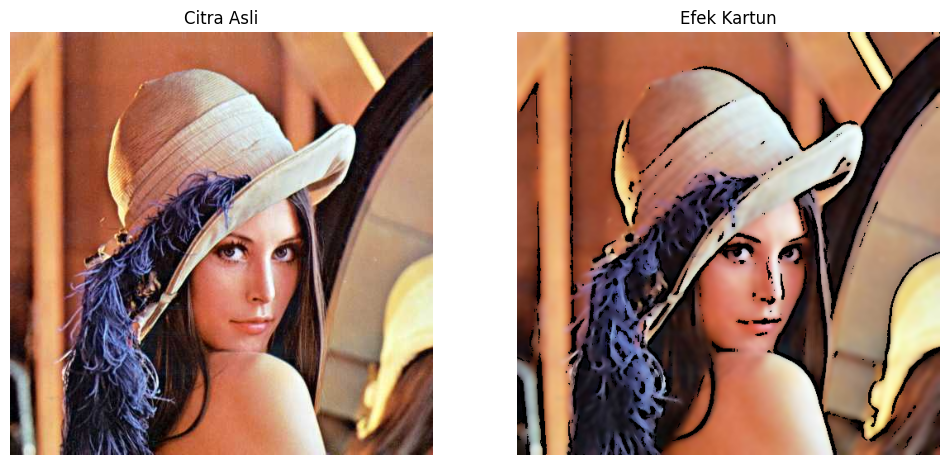

In [21]:
def kartun(image):
    warna_halus = cv.bilateralFilter(
        image,
        d=9,
        sigmaColor=200,
        sigmaSpace=200
    )
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray = cv.medianBlur(gray, 7)
    garis = cv.adaptiveThreshold(
        gray,
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        blockSize=9,
        C=9
    )
    hasil_kartun = cv.bitwise_and(warna_halus, warna_halus, mask=garis)
    return hasil_kartun
hasil_kartun = kartun(img_tugas)
show_side_by_side(
    [img_tugas, hasil_kartun],
    ["Citra Asli", "Efek Kartun"],
    figsize=(12, 6)
)


Bilateral Filter meratakan variasi warna pada suatu area tanpa menghilangkan batas objek sebanyak blur biasa. Adaptive Thresholding kemudian mengubah detail intensitas pada citra grayscale menjadi garis-garis hitam-putih yang menyerupai outline gambar kartun. Hasil kedua proses digabungkan sehingga area warna terlihat lebih sederhana dan rata, sementara garis tepi objek tetap tegas.
Hasil akhir memiliki karakteristik seperti ilustrasi kartun sederhana: jumlah variasi tekstur berkurang, area warna menjadi lebih halus, dan bentuk objek lebih ditekankan oleh outline.